# Подготовка шаблона


In [ ]:
%load_ext autoreload
%autoreload 2

import io
import cv2
import json
import numpy as np

from PIL import Image
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt

from utils import (
    generate_template,
    overlay_character,
    template_meta,
    build_triangulation,
    draw_triangulation,
    markup_skeleton,
    save_skeleton,
    animate_character,
    render_svg,
)

# --- параметры шаблона ---
CANVAS_SIZE = (1240, 1754)   # A4 @ 150 DPI (h, w)
MARKER_PX = 80
MARGIN = 60
CONTENT_PAD = 10

TITLE = "Sketch Factory"
OUTPUT_DIR = "output"

CHAR_ID = "001"
CHAR_DIR = f"templates/{CHAR_ID}"

meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)
print(f"Canvas:      {CANVAS_SIZE[1]}x{CANVAS_SIZE[0]}")
print(f"Drawing bbox: {meta['drawing_bbox']}")
print(f"Markers:      {meta['marker_centers']}")

## Пустой А4

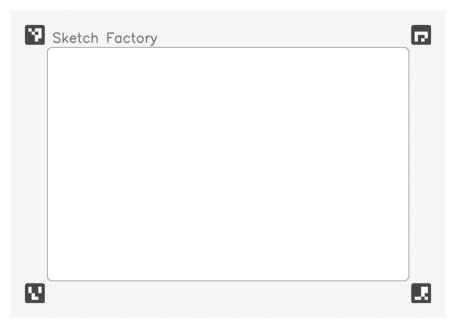

Сохранено: output\template.png


In [13]:
result = generate_template(
    output_path=f"{OUTPUT_DIR}/template.png",
    canvas_size=CANVAS_SIZE,
    marker_px=MARKER_PX,
    margin=MARGIN,
    content_pad=CONTENT_PAD,
    title=TITLE,
)

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(result["template"], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(f"Сохранено: {result['template_path']}")

## Наложение персонажа PNG

image_rect: [345, 244, 1064, 752]


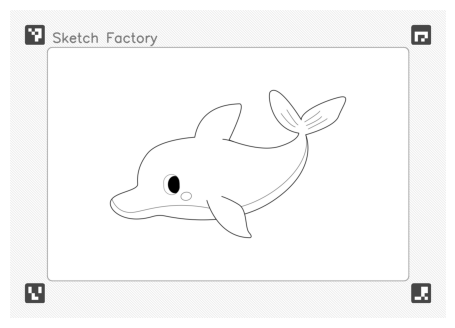

In [19]:
# SVG → шаблон для печати
result_char = overlay_character(
    template_path=f"{OUTPUT_DIR}/template.png",
    svg_path=f"{CHAR_DIR}/mask.svg",
    output_path=f"{CHAR_DIR}/template.png",
    content_scale=0.8,
    canvas_size=CANVAS_SIZE,
    marker_px=MARKER_PX,
    margin=MARGIN,
    content_pad=CONTENT_PAD,
)

print(f"image_rect: {result_char['image_rect']}")

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(result_char["template"], cv2.COLOR_BGR2RGB))
plt.axis("off"); plt.show()

## Разметка скелета

In [126]:
# --- Если нужна новая разметка ---
# img = render_svg(f"{CHAR_DIR}/mask.svg")
# keypoints = markup_skeleton(img)
# save_skeleton(img, keypoints, output_dir=CHAR_DIR, char_id=CHAR_ID)

# --- Загрузка готового ---
with open(f"{CHAR_DIR}/skeleton.json", encoding="utf-8") as f:
    skel = json.load(f)
keypoints = skel["keypoints"]
print(f"Загружено {len(keypoints)} точек: {list(keypoints.keys())}")

Загружено 11 точек: ['nose', 'upper_fin1', 'upper_fin2', 'lower_fin1', 'lower_fin2', 'left_tail1', 'right_tail1', 'center_tail1', 'center_tail2', 'center_tail3', 'head']


Триангуляция

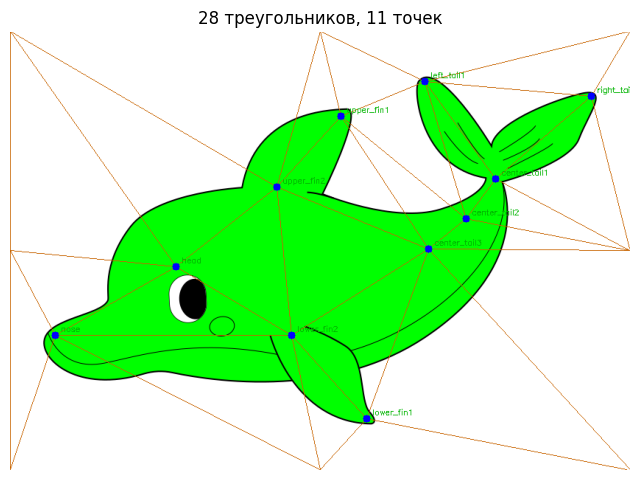

In [127]:
char_img = render_svg(f"{CHAR_DIR}/mask.svg")
th, tw = char_img.shape[:2]

ctrl_pts, tri, n_kp, names = build_triangulation(keypoints, tw, th)
vis = draw_triangulation(char_img, ctrl_pts, tri, n_kp, names)

plt.figure(figsize=(8, 6))
plt.imshow(vis)  # draw_triangulation уже возвращает RGBA
plt.axis("off")
plt.title(f"{len(tri.simplices)} треугольников, {n_kp} точек")
plt.show()

### Анимация

In [128]:
with open(f"{CHAR_DIR}/motion.json") as f:
    MOTION = json.load(f)
# MOTION

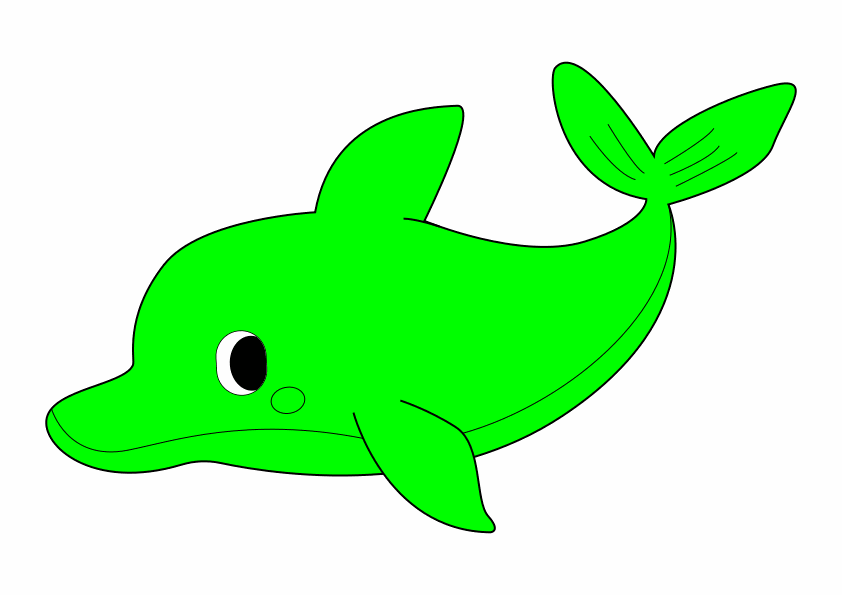

In [ ]:
char_img = render_svg(f"{CHAR_DIR}/mask.svg")
char_img = cv2.cvtColor(char_img, cv2.COLOR_RGBA2BGRA)

frames = animate_character(char_img, keypoints, MOTION)

pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA)) for f in frames]
buf = io.BytesIO()
pil_frames[0].save(buf, format="GIF", save_all=True, append_images=pil_frames[1:],
                   duration=1000 // 30, loop=0, disposal=2)
display(IPImage(data=buf.getvalue(), width=500))

### ARAP (As-Rigid-As-Possible) деформация

Вместо независимого аффинного варпа каждого треугольника — глобальная оптимизация,
которая сохраняет локальную жёсткость меша. Плюс более плотный меш (сетка внутри силуэта)
для гладкой деформации.

In [ ]:
import numpy as np, cv2, io, json, time
from PIL import Image
from IPython.display import Image as IPImage, display
from scipy.spatial import Delaunay, cKDTree
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import factorized
from utils import render_svg, warp_triangle, make_motion_from_config

# ── Config ─────────────────────────────────────────────────────
CHAR_ID    = "001"
CHAR_DIR   = f"templates/{CHAR_ID}"
MOTION_FILE = f"{CHAR_DIR}/motion_arap.json"   # отдельный конфиг для эксперимента
FPS        = 30
DURATION   = 3
PAD        = (50, 80, 0, 120)   # top, bottom, left, right
GRID_STEP  = 40                  # расстояние между точками внутренней сетки (px)
ARAP_ITERS = 3                   # итерации ARAP (2-4)

# ── Загрузка персонажа ─────────────────────────────────────────
with open(f"{CHAR_DIR}/skeleton.json") as f:
    kp_raw = json.load(f)["keypoints"]
with open(MOTION_FILE) as f:
    motion_cfg = json.load(f)

img = cv2.cvtColor(render_svg(f"{CHAR_DIR}/mask.svg"), cv2.COLOR_RGBA2BGRA)

# Паддинг (запас для движения)
pt, pb, pl, pr = PAD
oh, ow = img.shape[:2]
if any(p > 0 for p in PAD):
    img = cv2.copyMakeBorder(img, pt, pb, pl, pr,
                             cv2.BORDER_CONSTANT, value=(0, 0, 0, 0))
    kp_raw = {n: [(x * ow + pl) / img.shape[1],
                  (y * oh + pt) / img.shape[0]]
              for n, (x, y) in kp_raw.items()}

th, tw = img.shape[:2]
alpha = img[:, :, 3]

# ── Плотный меш ───────────────────────────────────────────────
kp_names = list(kp_raw.keys())
kp_pts = np.array([[v[0] * tw, v[1] * th] for v in kp_raw.values()],
                  dtype=np.float64)
n_kp = len(kp_pts)

# Внутренняя сетка — точки внутри силуэта
interior = []
for y in range(GRID_STEP // 2, th, GRID_STEP):
    for x in range(GRID_STEP // 2, tw, GRID_STEP):
        if alpha[y, x] > 128:
            interior.append([float(x), float(y)])
interior = np.array(interior, dtype=np.float64) if interior else np.empty((0, 2))

# Граничные якоря
corners = np.array([[0, 0], [tw, 0], [tw, th], [0, th],
                    [tw/2, 0], [tw, th/2], [tw/2, th], [0, th/2]],
                   dtype=np.float64)
n_corners = len(corners)

# Убираем внутренние точки слишком близкие к keypoints/углам
if len(interior):
    dists, _ = cKDTree(np.vstack([kp_pts, corners])).query(interior)
    interior = interior[dists > GRID_STEP * 0.6]
n_int = len(interior)

# Сборка: [keypoints | interior | corners]
V0 = np.vstack([kp_pts, interior, corners])
tri = Delaunay(V0)
N = len(V0)

# Хэндлы: keypoints (двигаются по motion) + corners (стоят на месте)
h_idx = list(range(n_kp)) + list(range(n_kp + n_int, N))
h_set = frozenset(h_idx)

print(f"Меш: {N} вершин ({n_kp} kp + {n_int} interior + {n_corners} boundary), "
      f"{len(tri.simplices)} треугольников")

# ── Визуализация меша ──────────────────────────────────────────
vis = cv2.cvtColor(img.copy(), cv2.COLOR_BGRA2RGBA)
for s in tri.simplices:
    pts_tri = V0[s].astype(np.int32)
    cv2.polylines(vis, [pts_tri], True, (200, 100, 0, 180), 1)
for i in range(n_kp):
    x, y = int(V0[i, 0]), int(V0[i, 1])
    cv2.circle(vis, (x, y), 6, (255, 0, 0, 255), -1)
    cv2.circle(vis, (x, y), 6, (255, 255, 255, 255), 2)
for i in range(n_kp, n_kp + n_int):
    x, y = int(V0[i, 0]), int(V0[i, 1])
    cv2.circle(vis, (x, y), 3, (0, 200, 0, 200), -1)

plt.figure(figsize=(8, 6))
plt.imshow(vis)
plt.axis("off")
plt.title(f"ARAP меш: {N} вершин, {len(tri.simplices)} треугольников "
          f"(красные = kp, зелёные = interior)")
plt.show()

# ── ARAP: предвычисления ──────────────────────────────────────
# Котангенсные веса
Wsp = lil_matrix((N, N))
for s in tri.simplices:
    for k in range(3):
        i, j, o = int(s[k]), int(s[(k+1) % 3]), int(s[(k+2) % 3])
        ei, ej = V0[i] - V0[o], V0[j] - V0[o]
        cross = abs(ei[0] * ej[1] - ei[1] * ej[0])
        cot = np.clip(np.dot(ei, ej) / (cross + 1e-8), 0.01, 100.0)
        Wsp[i, j] += 0.5 * cot
        Wsp[j, i] += 0.5 * cot
Wsp = Wsp.tocsr()

# Лапласиан с зафиксированными хэндлами
L = lil_matrix((N, N))
for i in range(N):
    row = Wsp[i]
    L[i, i] = row.sum()
    for j in row.indices:
        L[i, int(j)] -= row[0, int(j)]
for h in h_idx:
    L[h, :] = 0
    L[h, h] = 1.0
solve_L = factorized(L.tocsc())

# Списки соседей + рёбра для векторизации
_ei, _ej, _ew = [], [], []
for i in range(N):
    row = Wsp[i]
    for j, w in zip(row.indices.tolist(), row.data.tolist()):
        _ei.append(i); _ej.append(j); _ew.append(w)
E_i = np.array(_ei, dtype=np.intp)
E_j = np.array(_ej, dtype=np.intp)
E_w = np.array(_ew, dtype=np.float64)
E_orig = V0[E_i] - V0[E_j]    # (n_edges, 2) — не меняется
n_edges = len(E_i)

print(f"Рёбер: {n_edges}, факторизация L: done")

# ── ARAP солвер (векторизованный) ─────────────────────────────
def arap_solve(handle_targets):
    """handle_targets: (len(h_idx), 2) — целевые позиции хэндлов."""
    Vd = V0.copy()
    hmap = dict(zip(h_idx, handle_targets))
    for h in h_idx:
        Vd[h] = hmap[h]

    for _ in range(ARAP_ITERS):
        # ─ Local step: лучшая ротация на вершину (batch SVD) ─
        E_def = Vd[E_i] - Vd[E_j]
        outers = E_w[:, None, None] * (E_orig[:, :, None] * E_def[:, None, :])
        S = np.zeros((N, 2, 2))
        np.add.at(S, E_i, outers)

        U, _, Vt = np.linalg.svd(S)
        R = np.einsum('nji,nkj->nik', Vt, U)   # Vt.T @ U.T
        bad = np.linalg.det(R) < 0
        if bad.any():
            U[bad, :, -1] *= -1
            R[bad] = np.einsum('nji,nkj->nik', Vt[bad], U[bad])

        # ─ Global step: RHS + sparse solve ─
        R_sum = R[E_i] + R[E_j]
        contrib = 0.5 * E_w[:, None] * np.einsum('eij,ej->ei', R_sum, E_orig)
        b = np.zeros((N, 2))
        np.add.at(b, E_i, contrib)
        for k, h in enumerate(h_idx):
            b[h] = handle_targets[k]

        Vd[:, 0] = solve_L(b[:, 0])
        Vd[:, 1] = solve_L(b[:, 1])

    return Vd

# ── Генерация кадров ──────────────────────────────────────────
n_frames = FPS * DURATION
frames_arap = []
t0 = time.time()

for fi in range(n_frames):
    t = fi / n_frames

    # Целевые позиции keypoints (через существующий motion config)
    tmp = np.vstack([kp_pts, corners])
    moved = make_motion_from_config(t, tmp, n_kp, kp_names, motion_cfg)
    handle_targets = np.vstack([moved[:n_kp], corners])

    Vd = arap_solve(handle_targets)

    dst = np.zeros_like(img)
    for s in tri.simplices:
        warp_triangle(img, V0[s].tolist(), Vd[s].tolist(), dst)
    frames_arap.append(dst)

    if (fi + 1) % 15 == 0:
        elapsed = time.time() - t0
        print(f"  {fi+1}/{n_frames}  ({elapsed:.1f}s)")

print(f"Готово: {n_frames} кадров за {time.time()-t0:.1f}s")

# ── Показать GIF ──────────────────────────────────────────────
pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA))
              for f in frames_arap]
buf = io.BytesIO()
pil_frames[0].save(buf, format="GIF", save_all=True,
                   append_images=pil_frames[1:],
                   duration=1000 // FPS, loop=0, disposal=2)
display(IPImage(data=buf.getvalue(), width=500))

In [22]:
with open(f"{CHAR_DIR}/motion.json", "w") as f:
    json.dump(MOTION, f, indent=2)
print("Сохранено!")

Сохранено!


# RND